In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
import pandas as pd

data = {
    "PatientID": range(1, 21),
    "Age": [23, 45, 31, 52, 46, 29, 34, 41, 38, 27, 50, 36, 44, 33, 39, 48, 26, 42, 37, 30],
    "Gender": ["F","M","F","M","F","F","M","F","M","F","M","F","M","F","M","F","F","M","F","M"],
    "VisitType": ["Checkup","Emergency","Checkup","Emergency","Follow-up","Checkup","Emergency","Follow-up","Checkup","Emergency",
                  "Follow-up","Checkup","Emergency","Checkup","Follow-up","Emergency","Checkup","Follow-up","Emergency","Checkup"],
    "WaitingTime": [15, 45, 20, 60, 30, 25, 50, 35, 22, 55, 40, 18, 48, 28, 33, 52, 19, 37, 47, 26],
    "NoShow": ["No","Yes","No","Yes","No","No","Yes","No","No","Yes","No","No","Yes","No","No","Yes","No","No","Yes","No"]
}

df = pd.DataFrame(data)

In [3]:
df

,PatientID,Age,Gender,VisitType,WaitingTime,NoShow
0,1,23,F,Checkup,15,No
1,2,45,M,Emergency,45,Yes
2,3,31,F,Checkup,20,No
3,4,52,M,Emergency,60,Yes
4,5,46,F,Follow-up,30,No
5,6,29,F,Checkup,25,No
6,7,34,M,Emergency,50,Yes
7,8,41,F,Follow-up,35,No
8,9,38,M,Checkup,22,No
9,10,27,F,Emergency,55,Yes


<Axes: xlabel='Age', ylabel='Count'>

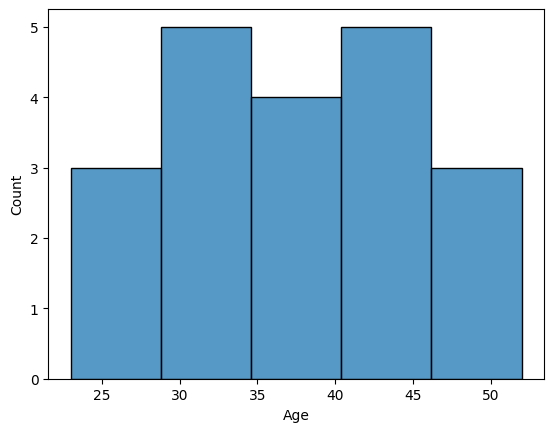

In [8]:
sns.histplot(df['Age'], bins = 5)

<Axes: xlabel='VisitType'>

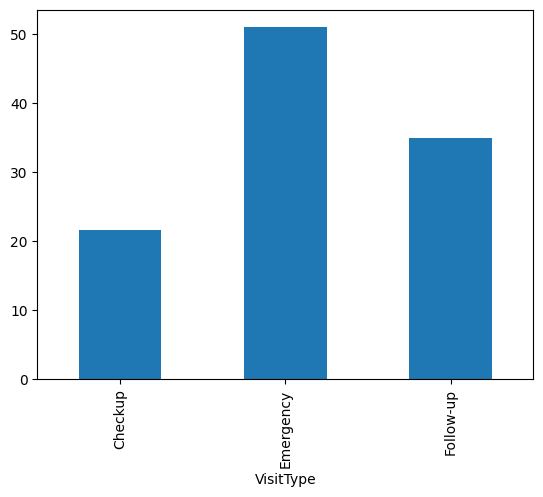

In [10]:
# Plot average waiting time by VisitType
avg_wait  = df.groupby('VisitType')['WaitingTime'].mean()
avg_wait.plot(kind = 'bar')

<Axes: xlabel='PatientID', ylabel='WaitingTime'>

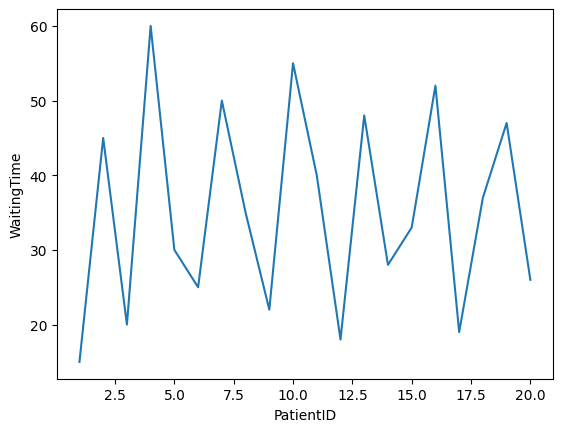

In [11]:
sns.lineplot(x = df['PatientID'], y = df['WaitingTime'])

<Axes: xlabel='NoShow', ylabel='count'>

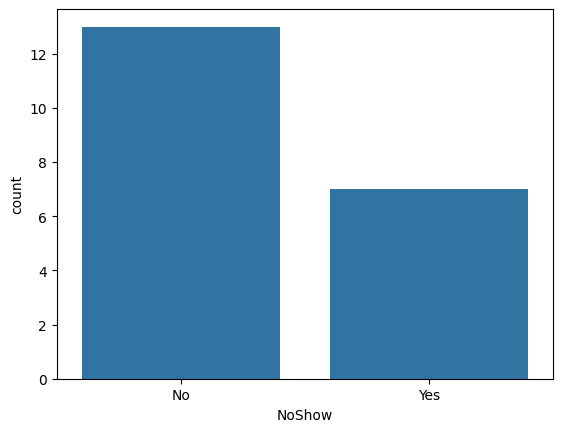

In [15]:
sns.countplot(x="NoShow", data=df)

In [13]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'VisitType', 'WaitingTime', 'NoShow'], dtype='str')

<Axes: xlabel='VisitType', ylabel='WaitingTime'>

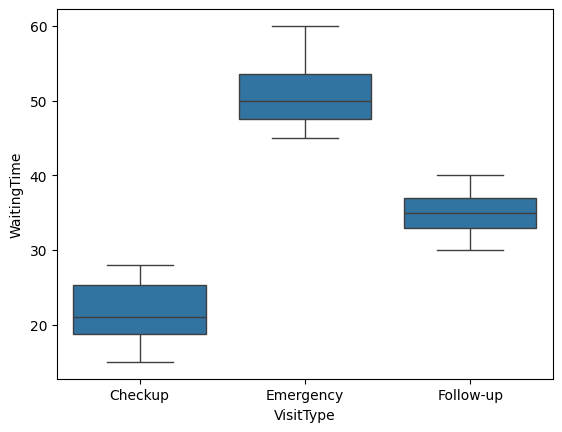

In [16]:
sns.boxplot(x = df['VisitType'], y = df['WaitingTime'])

<Axes: >

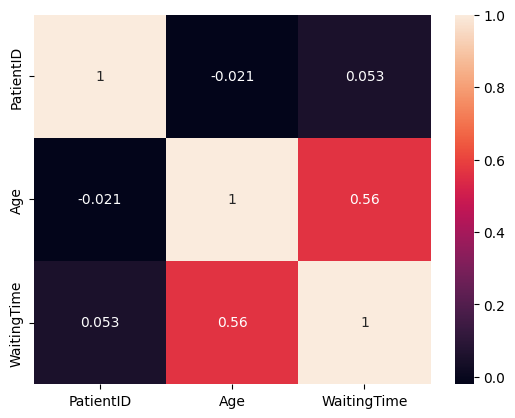

In [25]:
num_cols = df.select_dtypes(include = 'number')
corr = num_cols.corr()

sns.heatmap(corr, annot = True)

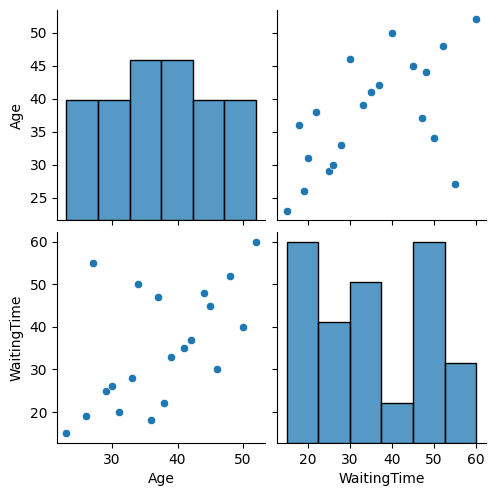

In [29]:
sns.pairplot(df[['Age','WaitingTime']])

# Plotly

In [2]:
!pip install plotly

In [6]:
import plotly.express as px

In [4]:
import sys
print(sys.executable)

C:\Users\rasha\anaconda3\envs\genai_env\python.exe


In [5]:
import sys
!{sys.executable} -m pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 4.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 4.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.1 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 4.1 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 4.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 4.1 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 4.1 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.0 MB/s  0:00:02

   ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [11]:
import sys
!{sys.executable} -m pip install nbformat


   -------------------- ------------------- 1/2 [nbformat]
   ---------------------------------------- 2/2 [nbformat]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


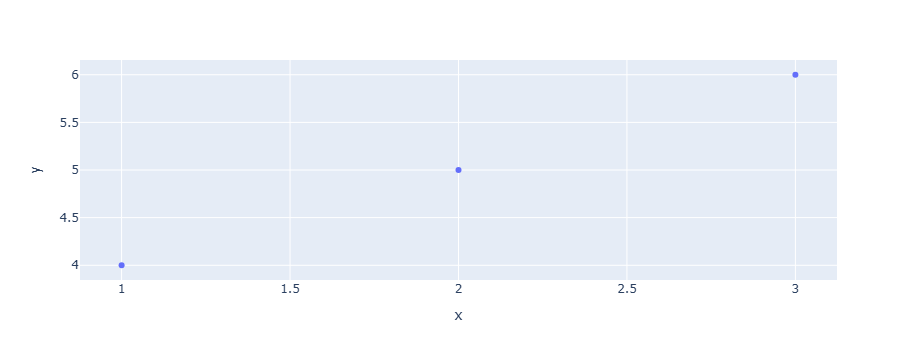

In [2]:
import plotly.express as px

px.scatter(x=[1,2,3], y=[4,5,6])

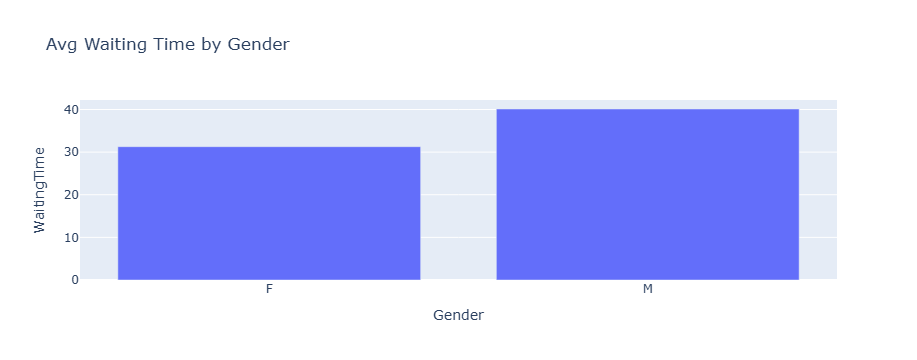

In [14]:
avg_wait_gender = df.groupby('Gender')['WaitingTime'].mean().reset_index()
px.bar(avg_wait_gender, x="Gender", y="WaitingTime",
             title="Avg Waiting Time by Gender")

In [6]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'VisitType', 'WaitingTime', 'NoShow'], dtype='str')

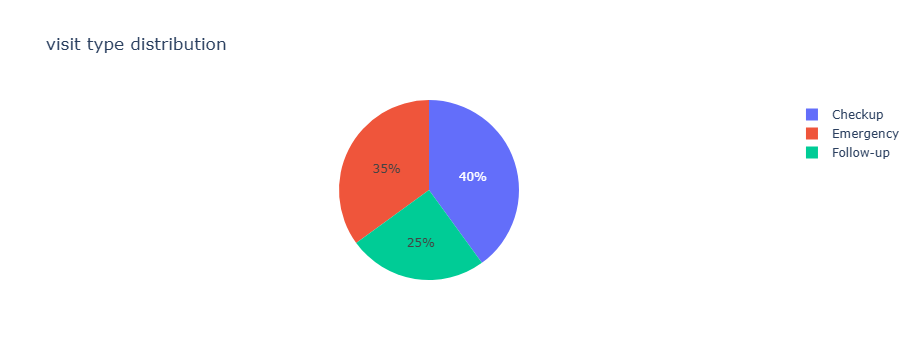

In [17]:
px.pie(df, names="VisitType",
             title="visit type distribution")

In [ ]:
# Insights

In [18]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'VisitType', 'WaitingTime', 'NoShow'], dtype='str')

In [36]:
# What is the overall no-show rate?
df['NoShow_encoded'] = df['NoShow'].apply(lambda x : 1 if x == 'Yes' else 0)
no_show_rate = df['NoShow_encoded'].sum() / len(df)
no_show_rate  # 35 percent

0.35

<Axes: xlabel='NoShow'>

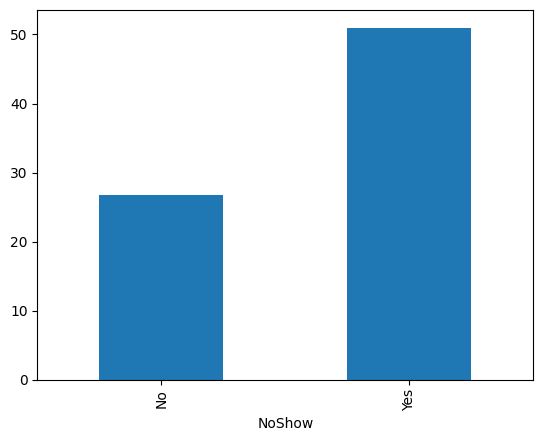

In [29]:
# Does waiting time impact no-shows?
r = df.groupby('NoShow')['WaitingTime'].mean()
r.plot(kind = 'bar')

In [ ]:
# patients with lengthy waiting times tend to leave without meeting the doctor

VisitType
Checkup      0.0
Emergency    1.0
Follow-up    0.0
Name: NoShow_encoded, dtype: float64

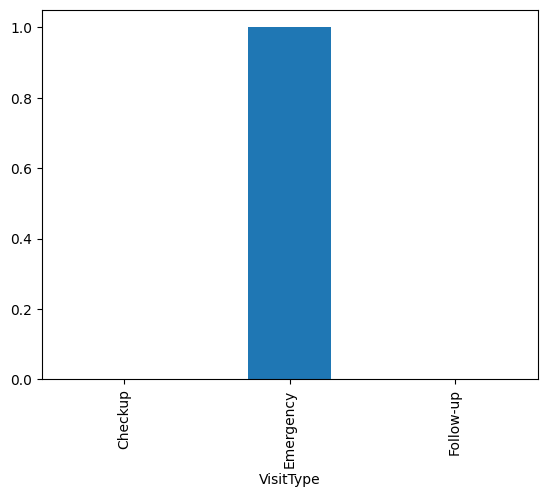

In [31]:
# Which VisitType has the highest no-show rate?
r = df.groupby('VisitType')['NoShow_encoded'].mean()
r.plot(kind = 'bar')
r

In [32]:
# Emergency has all no shows, might suggest patients who camein for medical emergency
# left without taking any services due to lengthy waiting times

,PatientID,Age,Gender,VisitType,WaitingTime,NoShow,NoShow_encoded
0,1,23,F,Checkup,15,No,0
1,2,45,M,Emergency,45,Yes,1
2,3,31,F,Checkup,20,No,0
3,4,52,M,Emergency,60,Yes,1
4,5,46,F,Follow-up,30,No,0
5,6,29,F,Checkup,25,No,0
6,7,34,M,Emergency,50,Yes,1
7,8,41,F,Follow-up,35,No,0
8,9,38,M,Checkup,22,No,0
9,10,27,F,Emergency,55,Yes,1


In [ ]:
# Do younger or older patients miss more appointments?


<Axes: xlabel='Gender'>

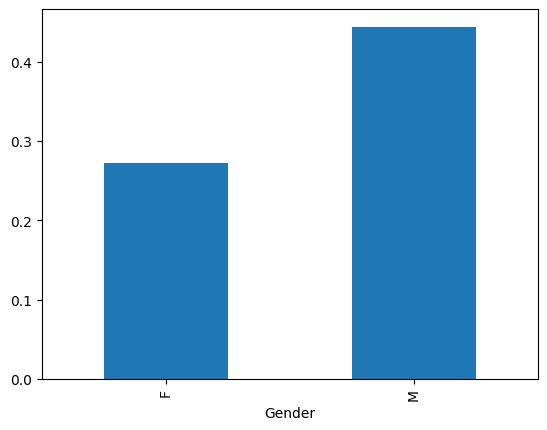

In [33]:
# Is there a gender difference in no-show rates?

r = df.groupby('Gender')['NoShow_encoded'].mean()
r.plot(kind = 'bar')

<Axes: xlabel='VisitType'>

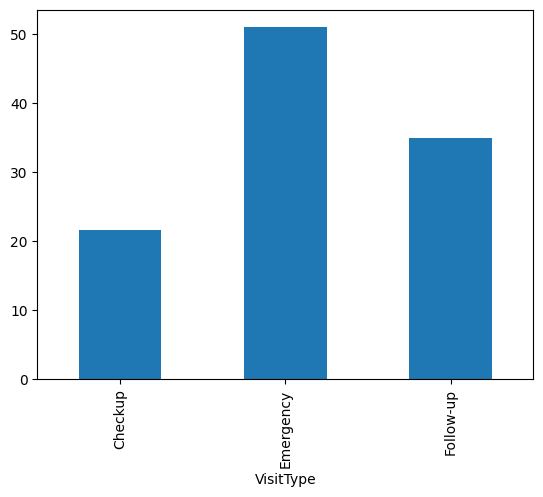

In [37]:
# Which VisitType has the longest waiting time?
avgwait = df.groupby('VisitType')['WaitingTime'].mean()
avgwait.plot(kind = 'bar')

<Axes: xlabel='VisitType'>

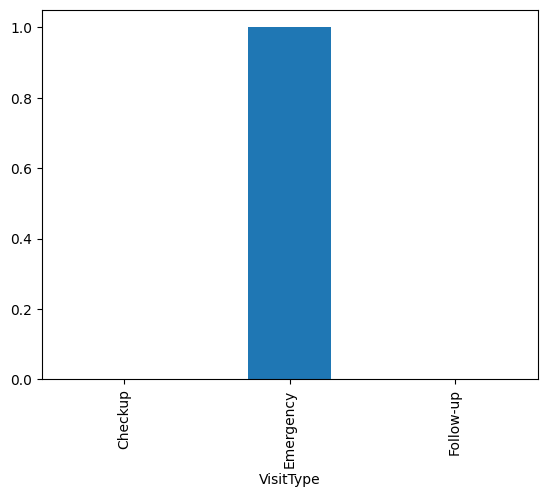

In [38]:
# Do emergency patients have lower no-show rates?  no thye have highest

avgwait = df.groupby('VisitType')['NoShow_encoded'].mean()
avgwait.plot(kind = 'bar')

<Axes: xlabel='NoShow'>

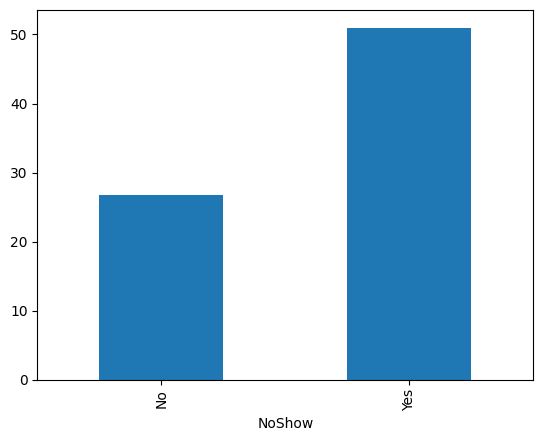

In [39]:
# What is the average waiting time for patients who showed up vs no-show?
r= df.groupby('NoShow')['WaitingTime'].mean()
r.plot(kind = 'bar')

In [40]:
no_show_rate = df.groupby("VisitType")["NoShow_encoded"].mean()

In [41]:
no_show_rate

VisitType
Checkup      0.0
Emergency    1.0
Follow-up    0.0
Name: NoShow_encoded, dtype: float64

group data across multiple dimensions like gender and visit type, 
calculate no-show rates, and identify high-risk combinations using aggregation and visualization.”

In [42]:
combo = df.groupby(["Gender", "VisitType"])["NoShow_encoded"].mean().reset_index()
combo

,Gender,VisitType,NoShow_encoded
0,F,Checkup,0.0
1,F,Emergency,1.0
2,F,Follow-up,0.0
3,M,Checkup,0.0
4,M,Emergency,1.0
5,M,Follow-up,0.0


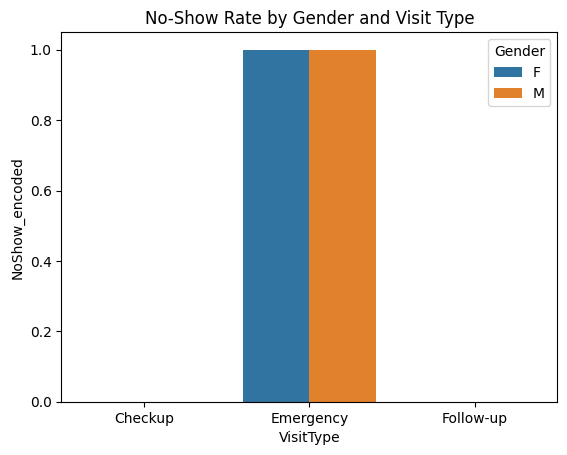

In [43]:
sns.barplot(x="VisitType", y="NoShow_encoded", hue="Gender", data=combo)
plt.title("No-Show Rate by Gender and Visit Type")
plt.show()

In [ ]:
# SQL queries

-- Are follow-up patients more reliable
select visittype, avg(case when noshow = 'Yes' then 1 else 0 end) as no_show_rate
from appoint
group by visittype

-- Which combination leads to highest no-show
select Gender, VisitType, avg(case when noshow = 'yes'  then 1 else 0 end) as noshowrate
from appoint
group by Gender, VisitType
order by noshowrate desc
limit 1

In [44]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'VisitType', 'WaitingTime', 'NoShow',
       'NoShow_encoded'],
      dtype='str')

-- Total number of patients
select count(patientid) as counts from appoint

-- Count of NoShow vs Show
select noshow, count(*) as counts
from appoint group by noshow

--Average waiting time
select avg(WaitingTime) from appoint

-- Number of patients by VisitType
select visittype, count(*) as counts
from appoints
group by visittype

-- Maximum and minimum waiting time
select max(waitingtime) as maxtime,
min(waitingtime)as mintime
from appoints

-- Average waiting time by VisitType
select VisitType, avg(waitingtime) as avgwaitingtime
from appoints
group by VisitType

-- No-show rate overall
select avg(case when noshow = 'yes' then 1 else 0 end) as noshowrate
from appoints

-- No-show rate by Gender
select gender, avg(case when noshow = 'yes' then 1 else 0 end) as noshowrate
from appoints
group by gender

-- Average waiting time for patients who showed up vs not
select noshow, avg(waitingtime) as noshowrate
from appoints
group by noshow

-- Top 3 highest waiting times
select * from appoint
order by waitingtime desc
limit 3

-- Which VisitType has highest no-show rate
select visittype, avg(case when noshow = 'yes' then 1 else 0 end) as noshowrate
from appoints group by visittype
ORDER BY no_show_rate DESC
LIMIT 1

-- Rank patients by waiting time (Window Function)
select *, dense_rank() over (order by waitingtime desc) as ranking
from appoints

- Running average of waiting time
select avg(waitingtime) over (order by patientid) as running_avg
from appoints

-- Find patients with above-average waiting time
select patientid, waitingtime from appoints
where waitingtime  > (select avg(waitingtime) from appoints)


-- Find highest no-show combination
select gender, visittype, avg(case when noshow = 'yes' then 1 else 0 end) as noshowrate
from appoints
group by gender, visittype
order by noshowrate desc
limit 1